In [2]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import kagglehub
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

2026-05-31 00:39:29.070981: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 00:39:29.306181: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 00:39:30.271657: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-31 00:39:33.202411: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
# ============================================================
# 2. DOWNLOAD DATASET
# ============================================================

path = kagglehub.dataset_download("feyzazkefe/trashnet")
dataset_dir = os.path.join(path, "dataset-resized")

print("Dataset path:", dataset_dir)
print("Classes:", os.listdir(dataset_dir))

Dataset path: /home/norah/.cache/kagglehub/datasets/feyzazkefe/trashnet/versions/1/dataset-resized
Classes: ['glass', 'metal', 'cardboard', 'paper', 'plastic', 'trash']


In [4]:
# ============================================================
# 3. DATASET INFORMATION
# ============================================================

class_counts = {}
total_images = 0
image_sizes = {}

for cls in os.listdir(dataset_dir):
    cls_path = os.path.join(dataset_dir, cls)

    if os.path.isdir(cls_path):
        files = os.listdir(cls_path)
        class_counts[cls] = len(files)
        total_images += len(files)

        for img_name in files:
            img_path = os.path.join(cls_path, img_name)

            try:
                img = Image.open(img_path)
                size = img.size
                image_sizes[size] = image_sizes.get(size, 0) + 1
            except:
                pass

print("Images per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

print("\nTotal images:", total_images)
print("Number of unique image sizes:", len(image_sizes))

print("\nImage sizes:")
for size, count in image_sizes.items():
    print(f"{size}: {count} images")

Images per class:
glass: 501
metal: 410
cardboard: 403
paper: 594
plastic: 482
trash: 137

Total images: 2527
Number of unique image sizes: 1

Image sizes:
(512, 384): 2527 images


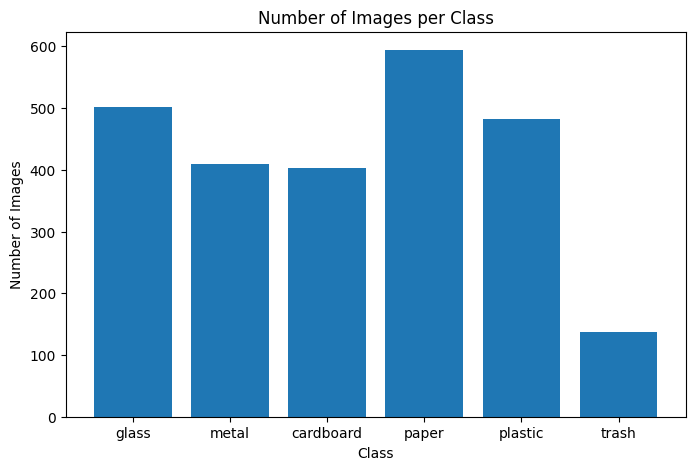

In [5]:
# ============================================================
# 4. CLASS DISTRIBUTION GRAPH
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

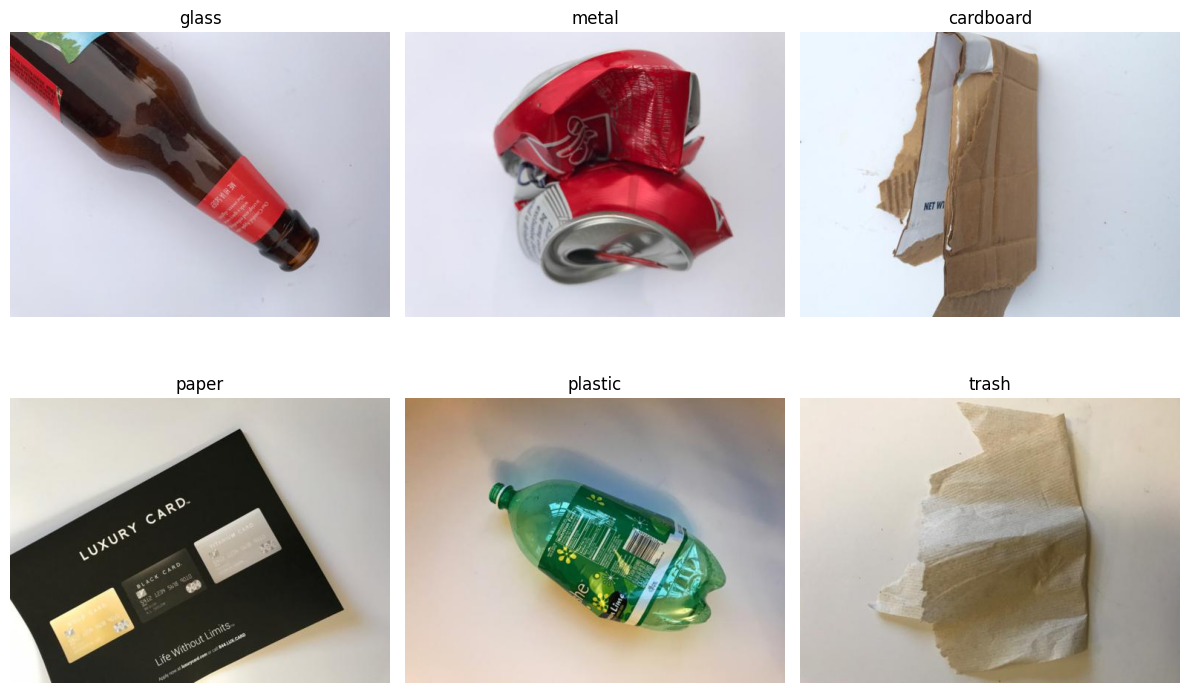

In [6]:
# ============================================================
# 5. VISUALIZE SAMPLE IMAGES
# ============================================================

classes = list(class_counts.keys())

plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    cls_path = os.path.join(dataset_dir, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# 6. IMAGE PROCESSING FUNCTIONS
# Median Filter and Gaussian Filter
# ============================================================

def median_filter_preprocess(img):
    img = img.astype(np.uint8)
    img = cv2.resize(img, (224, 224))
    
    # Median filter
    img = cv2.medianBlur(img, 3)
    
    img = preprocess_input(img.astype(np.float32))
    return img


def gaussian_filter_preprocess(img):
    img = img.astype(np.uint8)
    img = cv2.resize(img, (224, 224))
    
    # Gaussian filter
    img = cv2.GaussianBlur(img, (3, 3), 0)
    
    img = preprocess_input(img.astype(np.float32))
    return img

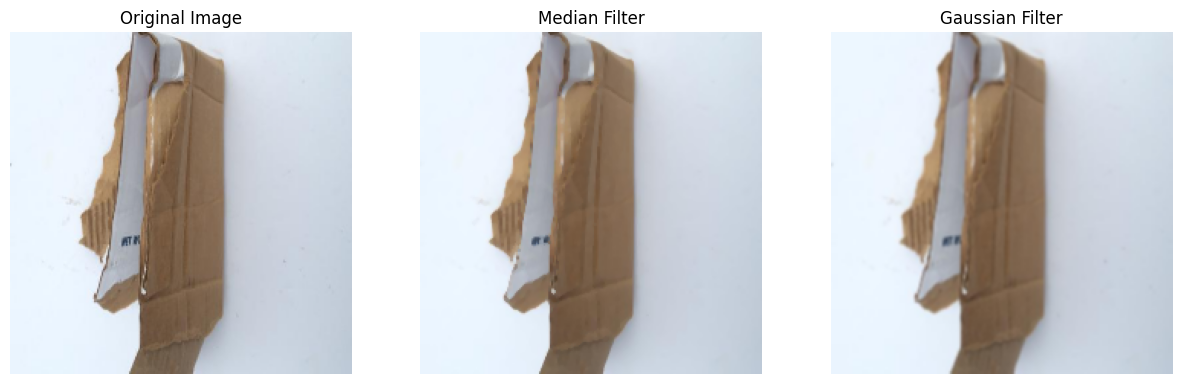

In [8]:
# ============================================================
# 7. VISUALIZE IMAGE PROCESSING EFFECT
# ============================================================

sample_class = classes[2]
sample_path = os.path.join(
    dataset_dir,
    sample_class,
    os.listdir(os.path.join(dataset_dir, sample_class))[0]
)

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

median_img = cv2.medianBlur(img, 3)
gaussian_img = cv2.GaussianBlur(img, (3, 3), 0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(median_img)
plt.title("Median Filter")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gaussian_img)
plt.title("Gaussian Filter")
plt.axis("off")

plt.show()

In [9]:
# ============================================================
# 8. CREATE DATA GENERATORS
# Original vs Median vs Gaussian
# ============================================================

img_size = (224, 224)
batch_size = 32

# Original images
original_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

# Median filter images
median_datagen = ImageDataGenerator(
    preprocessing_function=median_filter_preprocess,
    validation_split=0.2
)

# Gaussian filter images
gaussian_datagen = ImageDataGenerator(
    preprocessing_function=gaussian_filter_preprocess,
    validation_split=0.2
)

In [10]:
# ============================================================
# 9. ORIGINAL DATA
# ============================================================

original_train = original_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

original_val = original_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print("Class indices:", original_train.class_indices)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [11]:
# ============================================================
# 10. MEDIAN FILTER DATA
# ============================================================

median_train = median_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

median_val = median_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.


Found 503 images belonging to 6 classes.


In [12]:
# ============================================================
# 11. GAUSSIAN FILTER DATA
# ============================================================

gaussian_train = gaussian_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

gaussian_val = gaussian_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [13]:
# ============================================================
# 12. BUILD MobileNetV2 CLASSIFIER
# ============================================================

def build_model():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(128, activation="relu"),
        Dense(6, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [14]:
# ============================================================
# 13. TRAIN ORIGINAL MODEL
# ============================================================

original_model = build_model()

original_history = original_model.fit(
    original_train,
    validation_data=original_val,
    epochs=10
)

2026-05-31 00:39:47.781285: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-31 00:39:47.782488: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 68s 940ms/step - accuracy: 0.6744 - loss: 0.8941 - val_accuracy: 0.7316 - val_loss: 0.6929
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 806ms/step - accuracy: 0.8320 - loss: 0.4669 - val_accuracy: 0.7197 - val_loss: 0.7097
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 808ms/step - accuracy: 0.8631 - loss: 0.3725 - val_accuracy: 0.7097 - val_loss: 0.7543
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 860ms/step - accuracy: 0.9081 - loss: 0.2655 - val_accuracy: 0.7455 - val_loss: 0.7022
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 809ms/step - accuracy: 0.9200 - loss: 0.2305 - val_accuracy: 0.7674 - val_loss: 0.6564
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 798ms/step - accuracy: 0.9343 - loss: 0.1891 - val_accuracy: 0.7773 - val_loss: 0.6314
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 812ms/step - accuracy: 0.9353 - loss: 0.1892 - val_accuracy: 0.7515 - val_loss: 0.7546
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 861ms/step - accuracy: 0.9580 - loss: 0.1264 - val_accu

In [15]:
# ============================================================
# 14. TRAIN MEDIAN FILTER MODEL
# ============================================================

median_model = build_model()

median_history = median_model.fit(
    median_train,
    validation_data=median_val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 70s 984ms/step - accuracy: 0.6601 - loss: 0.9418 - val_accuracy: 0.6998 - val_loss: 0.7522
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 883ms/step - accuracy: 0.8192 - loss: 0.5052 - val_accuracy: 0.7276 - val_loss: 0.7256
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 859ms/step - accuracy: 0.8602 - loss: 0.3882 - val_accuracy: 0.7396 - val_loss: 0.7596
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 847ms/step - accuracy: 0.8770 - loss: 0.3149 - val_accuracy: 0.7217 - val_loss: 0.7259
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 862ms/step - accuracy: 0.9042 - loss: 0.2715 - val_accuracy: 0.7256 - val_loss: 0.7710
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 830ms/step - accuracy: 0.9239 - loss: 0.2193 - val_accuracy: 0.7237 - val_loss: 0.8400
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 819ms/step - accuracy: 0.9308 - loss: 0.1952 - val_accuracy: 0.7594 - val_loss: 0.7933
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 808ms/step - accuracy: 0.9427 - loss: 0.1632 - val_accu

In [16]:
# ============================================================
# 15. TRAIN GAUSSIAN FILTER MODEL
# ============================================================

gaussian_model = build_model()

gaussian_history = gaussian_model.fit(
    gaussian_train,
    validation_data=gaussian_val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 903ms/step - accuracy: 0.6621 - loss: 0.8988 - val_accuracy: 0.7157 - val_loss: 0.7312
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 870ms/step - accuracy: 0.8103 - loss: 0.5075 - val_accuracy: 0.7594 - val_loss: 0.6491
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 861ms/step - accuracy: 0.8587 - loss: 0.3790 - val_accuracy: 0.7217 - val_loss: 0.7387
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 866ms/step - accuracy: 0.8898 - loss: 0.3106 - val_accuracy: 0.7435 - val_loss: 0.7093
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 848ms/step - accuracy: 0.9071 - loss: 0.2571 - val_accuracy: 0.7634 - val_loss: 0.7008
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 867ms/step - accuracy: 0.9229 - loss: 0.2156 - val_accuracy: 0.7674 - val_loss: 0.6833
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 838ms/step - accuracy: 0.9382 - loss: 0.1818 - val_accuracy: 0.7674 - val_loss: 0.7282
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 831ms/step - accuracy: 0.9481 - loss: 0.1569 - val_accu

In [17]:
# ============================================================
# 16. COMPARE RESULTS
# ============================================================

original_acc = original_history.history["val_accuracy"][-1]
median_acc = median_history.history["val_accuracy"][-1]
gaussian_acc = gaussian_history.history["val_accuracy"][-1]

print("Original Images Validation Accuracy:", original_acc)
print("Median Filter Validation Accuracy:", median_acc)
print("Gaussian Filter Validation Accuracy:", gaussian_acc)

print("\nMedian Improvement:", median_acc - original_acc)
print("Gaussian Improvement:", gaussian_acc - original_acc)

Original Images Validation Accuracy: 0.7574552893638611
Median Filter Validation Accuracy: 0.7614313960075378
Gaussian Filter Validation Accuracy: 0.781312108039856

Median Improvement: 0.003976106643676758
Gaussian Improvement: 0.023856818675994873


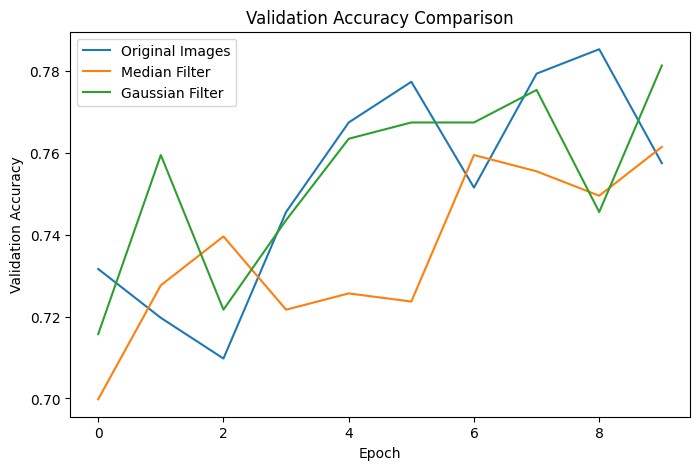

In [18]:
# ============================================================
# 17. PLOT VALIDATION ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(original_history.history["val_accuracy"], label="Original Images")
plt.plot(median_history.history["val_accuracy"], label="Median Filter")
plt.plot(gaussian_history.history["val_accuracy"], label="Gaussian Filter")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

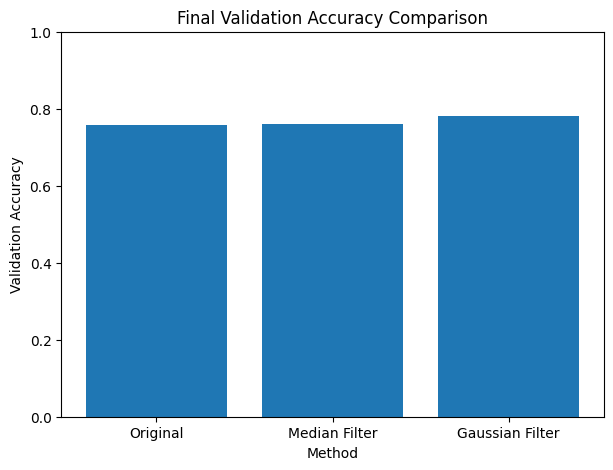

In [19]:
# ============================================================
# 18. BAR CHART FINAL ACCURACY
# ============================================================

methods = ["Original", "Median Filter", "Gaussian Filter"]
accuracies = [original_acc, median_acc, gaussian_acc]

plt.figure(figsize=(7, 5))
plt.bar(methods, accuracies)

plt.title("Final Validation Accuracy Comparison")
plt.xlabel("Method")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)

plt.show()

In [21]:
# ============================================================
# UNSHARP MASKING + HIGH-BOOST PREPROCESSING FUNCTIONS
# ============================================================

def unsharp_preprocess(img):
    img = img.astype(np.uint8)
    img = cv2.resize(img, (224, 224))

    # Blur image
    blurred = cv2.GaussianBlur(img, (5, 5), 1)

    # Unsharp masking
    sharpened = cv2.addWeighted(
        img, 1.5,
        blurred, -0.5,
        0
    )

    img = preprocess_input(sharpened.astype(np.float32))
    return img


def highboost_preprocess(img):
    img = img.astype(np.uint8)
    img = cv2.resize(img, (224, 224))

    # Blur image
    blurred = cv2.GaussianBlur(img, (5, 5), 1)

    # High-boost filtering
    highboost = cv2.addWeighted(
        img, 2.0,
        blurred, -1.0,
        0
    )

    img = preprocess_input(highboost.astype(np.float32))
    return img

In [22]:
unsharp_datagen = ImageDataGenerator(
    preprocessing_function=unsharp_preprocess,
    validation_split=0.2
)

highboost_datagen = ImageDataGenerator(
    preprocessing_function=highboost_preprocess,
    validation_split=0.2
)

In [23]:
unsharp_train = unsharp_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

unsharp_val = unsharp_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [24]:
highboost_train = highboost_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

highboost_val = highboost_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


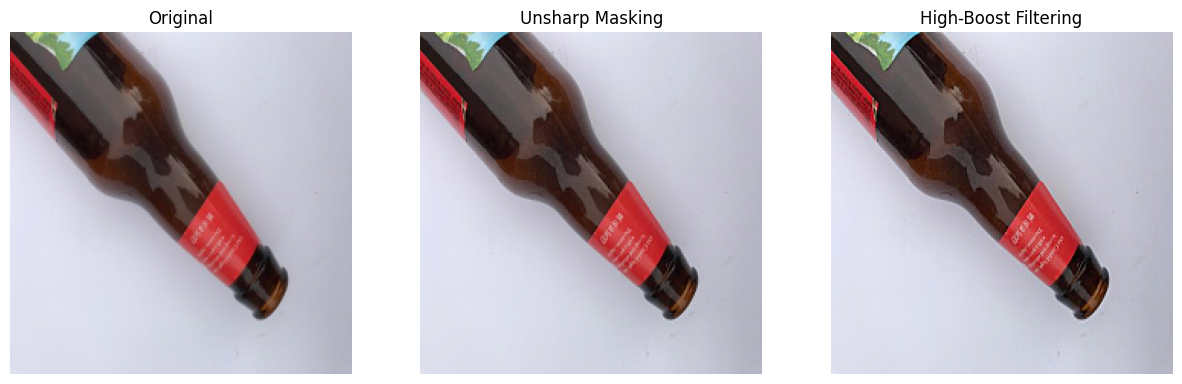

In [25]:
sample_class = classes[0]
sample_path = os.path.join(
    dataset_dir,
    sample_class,
    os.listdir(os.path.join(dataset_dir, sample_class))[0]
)

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

blurred = cv2.GaussianBlur(img, (5, 5), 1)
unsharp_img = cv2.addWeighted(img, 1.5, blurred, -0.5, 0)
highboost_img = cv2.addWeighted(img, 2.0, blurred, -1.0, 0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(unsharp_img)
plt.title("Unsharp Masking")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(highboost_img)
plt.title("High-Boost Filtering")
plt.axis("off")

plt.show()

In [26]:
unsharp_model = build_model()

unsharp_history = unsharp_model.fit(
    unsharp_train,
    validation_data=unsharp_val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 900ms/step - accuracy: 0.6749 - loss: 0.8920 - val_accuracy: 0.7058 - val_loss: 0.7013
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 845ms/step - accuracy: 0.8330 - loss: 0.4599 - val_accuracy: 0.7416 - val_loss: 0.6924
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 832ms/step - accuracy: 0.8814 - loss: 0.3315 - val_accuracy: 0.7058 - val_loss: 0.7731
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 907ms/step - accuracy: 0.8997 - loss: 0.2808 - val_accuracy: 0.7714 - val_loss: 0.6484
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 858ms/step - accuracy: 0.9145 - loss: 0.2268 - val_accuracy: 0.7594 - val_loss: 0.6593
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 843ms/step - accuracy: 0.9333 - loss: 0.1793 - val_accuracy: 0.7753 - val_loss: 0.6954
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 864ms/step - accuracy: 0.9452 - loss: 0.1687 - val_accuracy: 0.7634 - val_loss: 0.7048
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 847ms/step - accuracy: 0.9639 - loss: 0.1224 - val_accu

In [27]:
highboost_model = build_model()

highboost_history = highboost_model.fit(
    highboost_train,
    validation_data=highboost_val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 874ms/step - accuracy: 0.6640 - loss: 0.9122 - val_accuracy: 0.7555 - val_loss: 0.7434
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 845ms/step - accuracy: 0.8261 - loss: 0.4700 - val_accuracy: 0.7575 - val_loss: 0.6676
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 853ms/step - accuracy: 0.8602 - loss: 0.3988 - val_accuracy: 0.7913 - val_loss: 0.6581
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 837ms/step - accuracy: 0.8908 - loss: 0.2939 - val_accuracy: 0.7316 - val_loss: 0.8082
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 827ms/step - accuracy: 0.9234 - loss: 0.2254 - val_accuracy: 0.7714 - val_loss: 0.6820
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 830ms/step - accuracy: 0.9254 - loss: 0.1947 - val_accuracy: 0.7535 - val_loss: 0.6799
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 824ms/step - accuracy: 0.9373 - loss: 0.1722 - val_accuracy: 0.7674 - val_loss: 0.7147
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 834ms/step - accuracy: 0.9531 - loss: 0.1404 - val_accu

In [28]:
original_acc = original_history.history["val_accuracy"][-1]
median_acc = median_history.history["val_accuracy"][-1]
gaussian_acc = gaussian_history.history["val_accuracy"][-1]
unsharp_acc = unsharp_history.history["val_accuracy"][-1]
highboost_acc = highboost_history.history["val_accuracy"][-1]

print("Original Images Validation Accuracy:", original_acc)
print("Median Filter Validation Accuracy:", median_acc)
print("Gaussian Filter Validation Accuracy:", gaussian_acc)
print("Unsharp Masking Validation Accuracy:", unsharp_acc)
print("High-Boost Filtering Validation Accuracy:", highboost_acc)

print("\nGaussian Improvement:", gaussian_acc - original_acc)
print("Unsharp Improvement:", unsharp_acc - original_acc)
print("High-Boost Improvement:", highboost_acc - original_acc)

Original Images Validation Accuracy: 0.7574552893638611
Median Filter Validation Accuracy: 0.7614313960075378
Gaussian Filter Validation Accuracy: 0.781312108039856
Unsharp Masking Validation Accuracy: 0.7594433426856995
High-Boost Filtering Validation Accuracy: 0.737574577331543

Gaussian Improvement: 0.023856818675994873
Unsharp Improvement: 0.001988053321838379
High-Boost Improvement: -0.019880712032318115


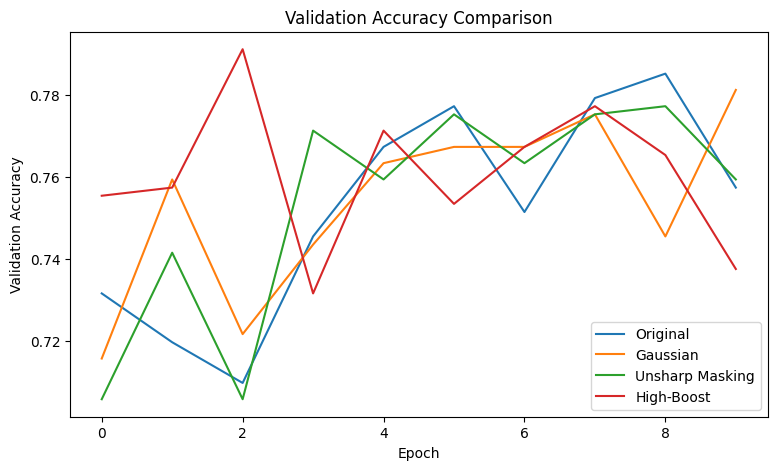

In [29]:
plt.figure(figsize=(9, 5))

plt.plot(original_history.history["val_accuracy"], label="Original")
plt.plot(gaussian_history.history["val_accuracy"], label="Gaussian")
plt.plot(unsharp_history.history["val_accuracy"], label="Unsharp Masking")
plt.plot(highboost_history.history["val_accuracy"], label="High-Boost")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

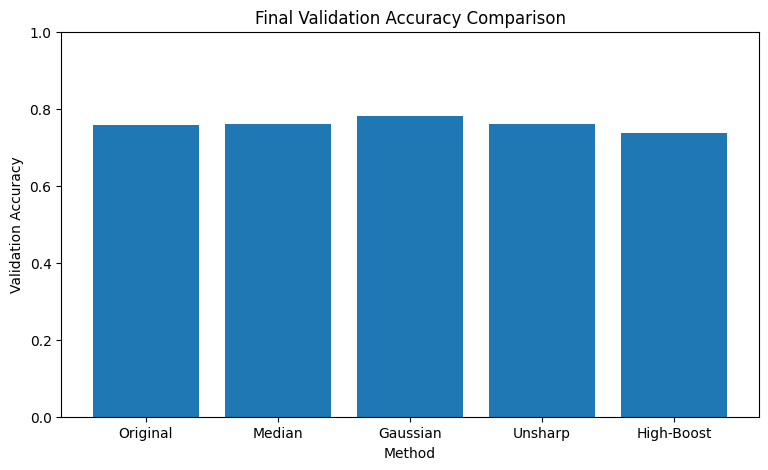

In [30]:
methods = [
    "Original",
    "Median",
    "Gaussian",
    "Unsharp",
    "High-Boost"
]

accuracies = [
    original_acc,
    median_acc,
    gaussian_acc,
    unsharp_acc,
    highboost_acc
]

plt.figure(figsize=(9, 5))
plt.bar(methods, accuracies)

plt.title("Final Validation Accuracy Comparison")
plt.xlabel("Method")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)

plt.show()

Gaussian filtering achieved the highest validation accuracy of 78.13%, compared to 75.75% for the original images. This shows that image preprocessing improved the CNN classification performance by reducing minor image variations while preserving the main object structure. However, high-boost filtering decreased accuracy because excessive sharpening may amplify edges and noise, making classification less stable.

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = gaussian_val.classes
y_pred_probs = gaussian_model.predict(gaussian_val)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(gaussian_val.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 926ms/step
              precision    recall  f1-score   support

   cardboard       0.92      0.72      0.81        80
       glass       0.73      0.84      0.78       100
       metal       0.76      0.87      0.81        82
       paper       0.80      0.91      0.85       118
     plastic       0.76      0.66      0.70        96
       trash       0.67      0.37      0.48        27

    accuracy                           0.78       503
   macro avg       0.77      0.73      0.74       503
weighted avg       0.78      0.78      0.78       503

[[ 58   1   2  15   2   2]
 [  0  84  10   2   4   0]
 [  0   5  71   2   4   0]
 [  5   2   1 107   2   1]
 [  0  23   5   3  63   2]
 [  0   0   4   5   8  10]]


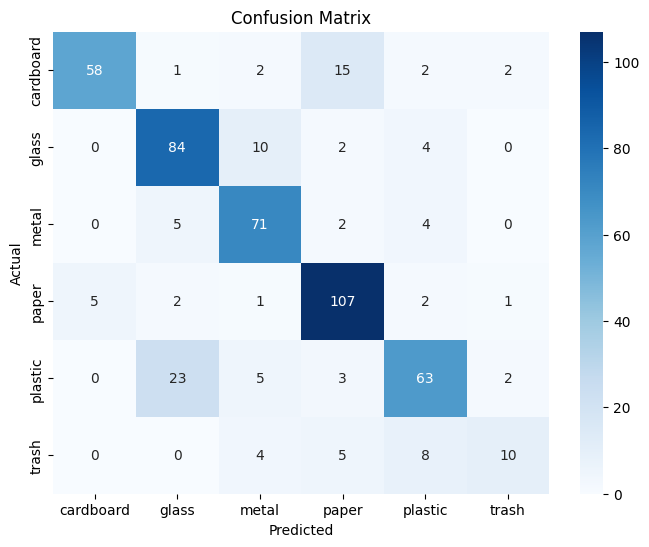

In [32]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The Gaussian-filtered MobileNetV2 model achieved an overall accuracy of 78%. The weighted average precision, recall, and F1-score were all 0.78, showing good and balanced performance across most classes.

The paper class had the best result with an F1-score of 0.85. Cardboard and metal also performed well, each with an F1-score of 0.81. The trash class had the lowest performance with an F1-score of 0.48 because it had fewer training images and looked similar to other waste categories.

The confusion matrix showed that most mistakes happened between plastic and glass because both often contain transparent objects that look alike.

Overall, applying the Gaussian filter improved the model’s performance compared to using the original images, showing that image preprocessing can help improve waste classification.


### Gaussian Filter = 78.13%

compare to:

### Original = 75.75%

the improvement :

### +2.38%

the final ranking:

1. **Gaussian Filter** = 78.13%
2. Median Filter = 76.14%
3. Unsharp Masking = 75.94%
4. Original = 75.75%
5. High-Boost = 73.75%

conclusion:

> Gaussian filtering achieved the best performance because it reduced minor image variations and background noise while preserving the overall structure of the waste objects. In contrast, high-boost filtering reduced accuracy because excessive sharpening may amplify edges and noise, making the model less stable.

so the Gaussian filter is the best to use as a preprocessing method


---------------------------
## Morphological Preprocessing Function

In [33]:
def morphology_preprocess(img):
    img = img.astype(np.uint8)

    # Resize
    img = cv2.resize(img, (224, 224))

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Otsu Threshold
    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Structuring element
    kernel = np.ones((5, 5), np.uint8)

    # Opening
    opened = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel
    )

    # Closing
    closed = cv2.morphologyEx(
        opened,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Apply mask to original image
    segmented = cv2.bitwise_and(
        img,
        img,
        mask=closed
    )

    # MobileNetV2 preprocessing
    segmented = preprocess_input(
        segmented.astype(np.float32)
    )

    return segmented

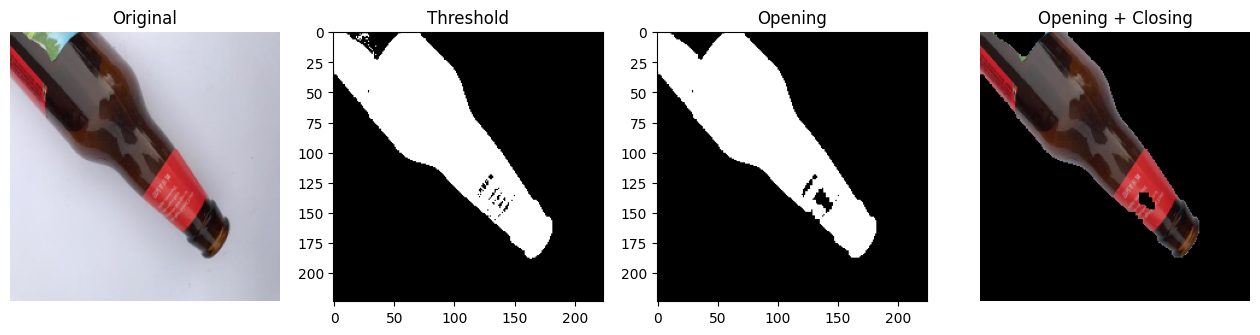

In [34]:
sample_class = classes[0]

sample_path = os.path.join(
    dataset_dir,
    sample_class,
    os.listdir(os.path.join(dataset_dir, sample_class))[0]
)

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

_, binary = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

kernel = np.ones((5,5), np.uint8)

opened = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)

closed = cv2.morphologyEx(
    opened,
    cv2.MORPH_CLOSE,
    kernel
)

segmented = cv2.bitwise_and(
    img,
    img,
    mask=closed
)

plt.figure(figsize=(16,5))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(binary, cmap="gray")
plt.title("Threshold")

plt.subplot(1,4,3)
plt.imshow(opened, cmap="gray")
plt.title("Opening")

plt.subplot(1,4,4)
plt.imshow(segmented)
plt.title("Opening + Closing")
plt.axis("off")

plt.show()

In [35]:
morph_datagen = ImageDataGenerator(
    preprocessing_function=morphology_preprocess,
    validation_split=0.2
)

morph_train = morph_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

morph_val = morph_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [36]:
morph_model = build_model()

morph_history = morph_model.fit(
    morph_train,
    validation_data=morph_val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 77s 987ms/step - accuracy: 0.5455 - loss: 1.1876 - val_accuracy: 0.6044 - val_loss: 1.0408
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 922ms/step - accuracy: 0.7050 - loss: 0.7755 - val_accuracy: 0.6342 - val_loss: 0.9850
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 874ms/step - accuracy: 0.7638 - loss: 0.6500 - val_accuracy: 0.6282 - val_loss: 1.0189
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 865ms/step - accuracy: 0.7974 - loss: 0.5752 - val_accuracy: 0.6501 - val_loss: 0.9927
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 898ms/step - accuracy: 0.8004 - loss: 0.5355 - val_accuracy: 0.6561 - val_loss: 0.9435
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 884ms/step - accuracy: 0.8325 - loss: 0.4602 - val_accuracy: 0.6342 - val_loss: 1.0651
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 848ms/step - accuracy: 0.8508 - loss: 0.4107 - val_accuracy: 0.6541 - val_loss: 0.9723
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 858ms/step - accuracy: 0.8676 - loss: 0.3777 - val_accu

In [37]:
morph_acc = morph_history.history["val_accuracy"][-1]

print("Original:", original_acc)
print("Gaussian:", gaussian_acc)
print("Morphology:", morph_acc)

Original: 0.7574552893638611
Gaussian: 0.781312108039856
Morphology: 0.6421471238136292
